# Análisis Exploratorio del Dataset de Popularidad de Canciones en Spotify

Este notebook explora el dataset de canciones de Spotify, compuesto por características de audio y la popularidad de cada tema. Identificaremos patrones, calidad de los datos y prepararemos la información para su posterior análisis y modelamiento, adaptado al contexto del proyecto.

## Configuración del Entorno y la Carga de Datos

Para garantizar la consistencia de este análisis, configuramos el entorno de trabajo para que sea dinámico. El código detecta automáticamente si se está ejecutando en la nube (Google Colab) o en un entorno local (Visual Studio Code), ajustando las rutas de los archivos.

**Primera validación de datos:** cargamos el dataset (`data/raw/spotify_tracks.csv`) aplicando una limpieza inicial con el parámetro `na_values`, para asegurar que strings vacíos o textos como "NULL"/"N/A" sean interpretados correctamente por Pandas como valores faltantes (`NaN`).

In [2]:
# Se importan las librerías necesarias para el análisis de datos y visualización
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Se ocultan advertencias para mantener el notebook limpio
warnings.filterwarnings('ignore') # Aveces aparecen advertencias molestas, que realmente no afectan al dataset

# Se configura la visualización para que se vea más profesional
sns.set_context("talk") # Eso escala automatiamente el de los elementos para las presentaciones
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.titlesize": 18, # Los titulos de los ejes se verán más grandes
        "axes.labelsize": 14, # Las etiquetas de los ejes se verán más grandes
        "xtick.labelsize": 12, # Esto enumera el tamaño de las etiquetas
        "ytick.labelsize": 12,
    },
)
plt.rcParams['figure.figsize'] = (10, 6) # Con esto se ajusta el tamaño de los gráficos

In [ ]:
# Detectar si estamos en Google Colab y ajustar la ruta del archivo
try:
    import google.colab
    IN_COLAB = True # Si funciona, estamos en la nube (colab)
except ImportError:
    IN_COLAB = False # Si falla, estamos en local (VSC)

# Se configura la ruta del archivo dependiendo del entorno
if IN_COLAB:
    print('Google Colab detectado. Sube el archivo.')
    from google.colab import files
    uploaded = files.upload() # Esto abre una ventana para seleccionar múltiples archivos
    if not uploaded:
        # Si se cancela la subida, se lanza un error
        raise FileNotFoundError('Debe subir el archivo a Colab antes de ejecutar el notebook.')
    ruta_base = '' # En Colab los archivos quedan en la raíz temporal
else:
    # Si no estamos en Colab, se asume que los archivos están en la ruta local
    ruta_base = '../data/raw/'

print("Iniciando la carga de los datos...")

# IMPORTANTE: verifiquen el nombre exacto del archivo descargado desde Kaggle
# (en algunos casos el CSV se llama 'dataset.csv')
ruta_archivo = os.path.join(ruta_base, 'dataset.csv')

df_final = pd.read_csv(
    ruta_archivo,
    na_values=['', 'NULL', 'null', 'N/A', 'NaN']
)

# Se hace una inspección rápida del dataset para entender su estructura
print(f"-> Canciones cargadas: {df_final.shape[0]} filas.")
print(f"Dimensiones del dataset final (df_final): {df_final.shape}") # Esto muestra cuantas filas y columnas tiene el dataset
df_final.head() # Esto muestra las primeras 5 filas del dataset para tener una idea de su contenido

Iniciando la carga de los datos...
-> Canciones cargadas: 114000 filas.
Dimensiones del dataset final (df_final): (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [12]:
# Cuenta cuántas canciones hay por cada género musical
df_final['track_genre'].value_counts()

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64

## Diccionario de variables clave

| Variable | Descripción |
|---|---|
| `track_id` | Identificador único de la canción en Spotify |
| `artists` | Artista(s) de la canción |
| `album_name` | Nombre del álbum |
| `track_name` | Nombre de la canción |
| `popularity` | Puntaje de popularidad (0-100), **variable objetivo** |
| `duration_ms` | Duración de la canción en milisegundos |
| `explicit` | Si la canción tiene contenido explícito (True/False) |
| `danceability` | Qué tan "bailable" es la canción (0.0-1.0) |
| `energy` | Intensidad y actividad percibida (0.0-1.0) |
| `key` | Tonalidad musical (0-11, notación de clases de tono) |
| `loudness` | Volumen general en decibeles (dB) |
| `mode` | Modalidad (1 = mayor, 0 = menor) |
| `speechiness` | Presencia de palabras habladas (0.0-1.0) |
| `acousticness` | Confianza de que la canción es acústica (0.0-1.0) |
| `instrumentalness` | Predicción de ausencia de voz (0.0-1.0) |
| `liveness` | Detección de presencia de audiencia en vivo (0.0-1.0) |
| `valence` | Positividad musical transmitida (0.0-1.0) |
| `tempo` | Tempo estimado en BPM |
| `time_signature` | Compás estimado |
| `track_genre` | Género musical de la canción |


### Inspección de datos:

Al analizar el resultado de `info()`, descubrimos aspectos importantes sobre la calidad de los datos que guiarán nuestro preprocesamiento:

1. **Nulos mínimos, pero no cero:** Las variables `artists`, `album_name` y `track_name` presentan **114.000 vs 113.999** registros no nulos, es decir, solo **1 fila con valores faltantes**. A diferencia de datasets con perfiles de usuario incompletos, aquí el volumen de nulos es prácticamente insignificante, por lo que la estrategia más simple y razonable es eliminarla directamente, sin necesidad de imputación.

2. **Tipos de datos ya correctos y bien definidos:** A diferencia de catálogos menos estructurados, este dataset viene con los tipos de datos ya optimizados desde su origen: `explicit` ya es de tipo `bool`, y las variables de audio (`danceability`, `energy`, `valence`, etc.) ya están en `float` listas para el análisis. Sin embargo, variables como `key`, `mode` y `time_signature` son en realidad **categóricas codificadas como números** (ej. `mode` solo toma valores 0 o 1), por lo que deberemos evaluar si tratarlas como numéricas o convertirlas a categóricas antes de modelar.

3. **Variables identificatorias sin valor predictivo directo:** Columnas como `track_id`, `track_name`, `album_name` y `artists` son de tipo texto (`str`), pero a diferencia de un campo como una reseña de usuario, no contienen información desestructurada que requiera NLP para este análisis, ya que son principalmente identificadores. Su utilidad está en saber qué canción es cada fila, no como input directo del modelo, por lo que deberán excluirse al momento de construir el set de entrenamiento.

4. **Volumen de datos manejable:** Con 114.000 registros y un uso de memoria de solo 26.8 MB, el dataset es liviano y no representa un desafío de rendimiento como sí lo sería un dataset de un millón de filas. El principal riesgo de volumen no está en el tamaño del dataset en sí, sino en la **codificación de `track_genre`** (114 categorías distintas): aplicar one-hot encoding sobre esta variable generará más de 100 columnas nuevas, lo que deberemos considerar al preparar los datos para el modelamiento.

In [14]:
# Información general del dataset
print('Información del dataset:')
df_final.info() # Nos muestra el tipo de datos de cada columna y cuántos valores no nulos que tiene

print("\n" + "="*50 + "\n") # Esto es solo para separar visualmente las secciones del notebook

print('\nResumen estadístico de variables numéricas:')
df_final.describe(include='all').T # Esto nos genera estadísticas descriptivas para todas las variables

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  livene

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,NaN,NaN,NaN,56999.5,32909.109681,0.0,28499.75,56999.5,85499.25,113999.0
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,113999,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,113999,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,113999,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,114000.0,NaN,NaN,NaN,33.238535,22.305078,0.0,17.0,35.0,50.0,100.0
duration_ms,114000.0,NaN,NaN,NaN,228029.153114,107297.712645,0.0,174066.0,212906.0,261506.0,5237295.0
explicit,114000,2,False,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,114000.0,NaN,NaN,NaN,0.5668,0.173542,0.0,0.456,0.58,0.695,0.985
energy,114000.0,NaN,NaN,NaN,0.641383,0.251529,0.0,0.472,0.685,0.854,1.0


### Limpieza Estructural y Detección de Valores Nulos

Antes de proceder con el análisis exploratorio, realizaremos una limpieza estructural básica sobre el dataset:

1. **Eliminación de columnas irrelevantes:** Descartaremos la columna `Unnamed: 0`, un índice residual que no aporta valor predictivo ni analítico.
2. **Eliminación de registros corruptos:** Se identificó un registro (índice 65900) sin metadata (`artists`, `album_name`, `track_name` nulos) y con `duration_ms = 0`, lo que indica una fila corrupta y no una canción real. Este registro será eliminado.
3. **Cuantificación de datos faltantes:** Calcularemos el volumen de valores nulos restantes en el dataset, para confirmar que la limpieza fue efectiva antes de continuar con el análisis.

In [21]:
# Se eliminan las columnas que son innecesarias

# Se define en una lista el nombre a eliminar
columnas_a_eliminar = ['Unnamed: 0'] # Unnamed: 0 -> Suele aparecer como basura
# Se ocupa un filtro de seguridad que revisa que realmente existe la fila antes de eliminarla
columnas_a_eliminar = [c for c in columnas_a_eliminar if c in df_final.columns] # Además evita que el programa tire un error si la fila no existe
df_final = df_final.drop(columns=columnas_a_eliminar)

# Se eliminan las filas que son innecesarias

# Se elimina la fila específica con el índice 65900
df_final = df_final.drop(index=65900, errors='ignore').reset_index(drop=True) 

# Se calculan los valores faltantes

nulos = df_final.isnull().sum() # .isnull() -> evalúa cada celda para ver si está vacía
# Se calcula el porcentaje de nulos y con len(df_final) obtenemos el total de filas del dataset
porcentaje_nulos = (nulos / len(df_final)) * 100
# Se crea un nuevo DataFrame
resumen_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje': porcentaje_nulos.round(2)
}).sort_values('porcentaje', ascending=False) # .sort_values() ordena la tabla, poniendo arriba las columnas con más nulos

# Se visualiza el resultado

resumen_nulos[resumen_nulos['nulos'] > 0]

,nulos,porcentaje


### Análisis de duplicados
Se evalúa si existen filas duplicadas usando `.duplicated().sum()`.

In [22]:
# Se muestra el número de filas duplicadas (exactas) en el dataset final
duplicados = df_final.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

# También revisar duplicados por track_id, ya que una canción
# puede repetirse en distintos géneros del dataset
if 'track_id' in df_final.columns:
    duplicados_por_id = df_final.duplicated(subset=['track_id']).sum()
    print(f"Número de track_id duplicados: {duplicados_por_id}")

    pct_dup_id = (duplicados_por_id / len(df_final)) * 100
    print(f"Porcentaje de track_id duplicados: {pct_dup_id:.2f}%")

# Porcentaje de duplicados exactos sobre el total
pct_dup = (duplicados / len(df_final)) * 100
print(f"Porcentaje de filas exactamente duplicadas: {pct_dup:.4f}%")

Número de filas duplicadas: 450
Número de track_id duplicados: 24259
Porcentaje de track_id duplicados: 21.28%
Porcentaje de filas exactamente duplicadas: 0.3947%


### Conclusiones del Análisis

El análisis de valores faltantes y registros duplicados permitió identificar aspectos relevantes que deberán considerarse en las etapas posteriores de preprocesamiento.

1. **Ausencia de valores nulos tras la limpieza estructural:** A diferencia de datasets con perfiles de usuario incompletos, este dataset presentó un único registro corrupto (índice 65900, sin metadata y con `duration_ms = 0`), el cual ya fue eliminado. Tras esta limpieza, el dataset no presenta valores nulos en ninguna columna.

2. **Duplicados por `track_id` (21.28%) — no representan un error:** Se identificaron 24.259 registros con `track_id` repetido. Al investigar la causa, se confirmó que corresponden a canciones catalogadas legítimamente en múltiples géneros musicales (hasta 9 géneros distintos para una misma canción), y no a errores de carga. **No serán eliminados**, ya que representan información válida sobre la clasificación multi-género de Spotify.

3. **Aparición de duplicados exactos tras eliminar la columna de índice (450 filas, 0.39%):** Inicialmente no se detectaban duplicados exactos, ya que la columna `Unnamed: 0` (un índice secuencial) hacía que cada fila pareciera única. Al eliminar esta columna por no aportar valor analítico, se revelaron 450 filas verdaderamente idénticas en todo su contenido (mismo `track_id`, género y características de audio). A diferencia de los duplicados por multi-género, estos sí corresponden a registros redundantes sin información adicional, por lo que **serán eliminados** en la etapa de preparación de datos.

4. **Valores de `tempo = 0` concentrados en el género "sleep" (157 casos, 0.14%):** Se identificó que el 88% de estos casos corresponde a música ambiental/para dormir, donde el algoritmo de Spotify no logra detectar un pulso rítmico. No se tratan como error, sino como una característica genuina del género; se evaluará su imputación únicamente si `tempo` se utiliza como variable predictora en el modelamiento.

5. **Variable objetivo (`popularity`) sin valores faltantes:** A diferencia de datasets donde la variable objetivo presenta nulos que deben excluirse antes del entrenamiento, `popularity` no presenta ningún valor faltante en este dataset, por lo que no se requiere un tratamiento especial en este aspecto.

In [23]:
# Se eliminan los duplicados exactos detectados tras remover la columna de índice
df_final = df_final.drop_duplicates().reset_index(drop=True)
print(f"Filas después de eliminar duplicados exactos: {df_final.shape[0]}")

Filas después de eliminar duplicados exactos: 113549


Generando mapa de calor... (esto puede tomar unos segundos)


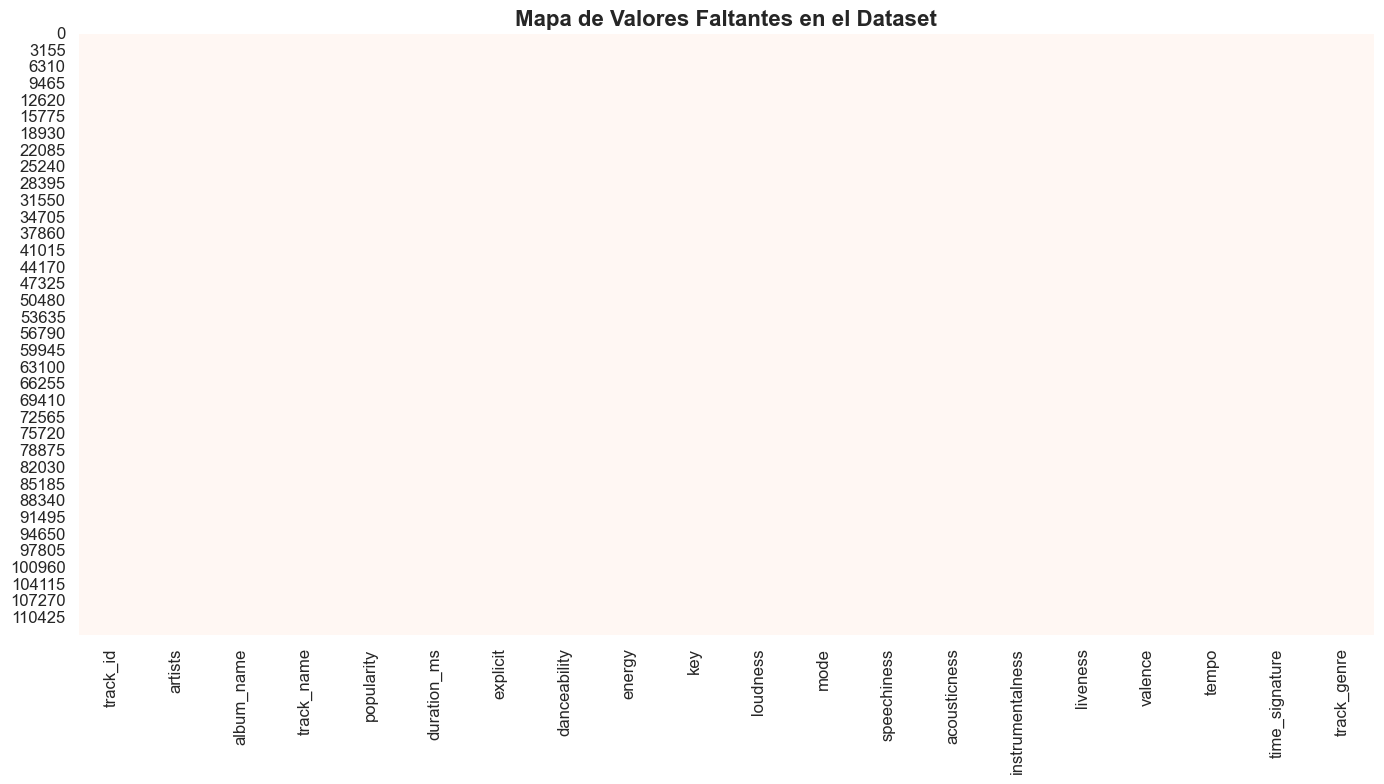

In [25]:
# Se genera un mapa de calor para visualizar la distribución de los valores faltantes en el dataset
print("Generando mapa de calor... (esto puede tomar unos segundos)")

plt.figure(figsize=(14, 8))
# Se visualizan los nulos
sns.heatmap(df_final.isnull(), cbar=False, cmap='RdPu')

plt.title("Mapa de Valores Faltantes en el Dataset", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Confirmación visual de la limpieza de nulos**

El mapa de calor confirma que, tras la eliminación del registro corrupto, el dataset no presenta valores faltantes en ninguna columna.

## Estadísticas descriptivas

In [ ]:
# Se muestra el número de columnas numéricas y categóricas (object) para entender la composición del dataset
columnas_numericas = df_final.select_dtypes(include=np.number).columns.tolist()
columnas_categoricas = df_final.select_dtypes(include='object').columns.tolist()

print(f"Columnas numéricas ({len(columnas_numericas)}): {columnas_numericas}")
print(f"\nColumnas categóricas ({len(columnas_categoricas)}): {columnas_categoricas}")

df_final[columnas_numericas].describe().T

### Conclusiones de las Estadísticas Descriptivas

> _Completar: ¿hay variables con rangos inesperados (ej. tempo=0)? ¿alguna variable de audio está muy sesgada hacia un valor? ¿la variable `popularity` tiene muchos ceros?_

## Análisis de la variable objetivo (`popularity`)

In [ ]:
# Se define el nombre de la variable objetivo que será utilizada en los modelos supervisados
variable_objetivo = 'popularity'

plt.figure(figsize=(10, 6))
sns.histplot(df_final[variable_objetivo], bins=30, kde=True, color='#9b59b6')
plt.title("Distribución de la Popularidad de las Canciones", fontsize=16, fontweight="bold")
plt.xlabel("Popularidad (0-100)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print(df_final[variable_objetivo].describe())

### Conclusiones del Análisis de la Variable Objetivo

> _Completar: ¿la distribución es normal, sesgada, o tiene muchos valores en 0? ¿esto sugiere trabajar el problema como regresión o como clasificación (ej. popular vs. no popular con un umbral)?_

## Análisis de variables categóricas principales

### Análisis de Variables Categóricas

Se analizan las variables categóricas más relevantes para el negocio, como el género musical (`track_genre`) y los artistas con mayor presencia en el dataset.

In [ ]:
# Se exploran los géneros con mayor popularidad promedio
if 'track_genre' in df_final.columns:
    popularidad_por_genero = (
        df_final.groupby('track_genre')[variable_objetivo]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 8))
    sns.barplot(x=popularidad_por_genero.values, y=popularidad_por_genero.index, palette='magma')
    plt.title("Top 15 Géneros por Popularidad Promedio", fontsize=16, fontweight="bold")
    plt.xlabel("Popularidad promedio")
    plt.ylabel("Género")
    plt.tight_layout()
    plt.show()

## Análisis de distribución

### Análisis de Distribuciones Numéricas

In [ ]:
# Se seleccionan únicamente las variables numéricas de audio relevantes
features_audio = ['danceability', 'energy', 'loudness', 'speechiness',
                   'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
features_audio = [f for f in features_audio if f in df_final.columns]

df_final[features_audio].hist(bins=25, figsize=(16, 12), color='#8e44ad', edgecolor='black')
plt.suptitle("Distribución de las Características de Audio", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

## Detección de Outliers

### Detección de Valores Atípicos (Outliers)

In [ ]:
# Se utilizan las variables numéricas continuas identificadas previamente
plt.figure(figsize=(16, 8))
df_final[features_audio].boxplot(rot=45)
plt.title("Detección de Outliers en Features de Audio", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Análisis de Correlación

### Análisis de Correlación

In [ ]:
# Se calcula la matriz de correlación utilizando únicamente variables numéricas
corr_matrix = df_final.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
paleta_verde_morado = sns.diverging_palette(280, 150, s=85, l=50, as_cmap=True)

sns.heatmap(
    corr_matrix,
    cmap=paleta_verde_morado,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title("Matriz de Correlación de Pearson (Variables Numéricas)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

if variable_objetivo in corr_matrix.columns:
    correlaciones_popularidad = (
        corr_matrix[variable_objetivo]
        .drop(variable_objetivo)
        .sort_values(ascending=False)
    )
    print("\n=== Correlaciones con popularity (mayor a menor) ===")
    display(correlaciones_popularidad)

### Interpretación de la Matriz de Correlación

> _Completar con los hallazgos reales, siguiendo este formato:_
> 1. **Variables más correlacionadas con `popularity`:** ¿cuáles features de audio tienen mayor relación (positiva o negativa)?
> 2. **Multicolinealidad:** ¿hay variables de audio muy correlacionadas entre sí (ej. `energy` y `loudness`)? ¿qué implicancia tiene esto para un futuro modelo?
> 3. **Variables poco relevantes:** ¿qué features tienen correlación cercana a 0 con la popularidad?

## Preparación de Datos para el Modelamiento

Con base en los hallazgos del EDA, se preparan los datos para que puedan ser utilizados en un futuro proceso de modelamiento.

In [ ]:
# 1. Tratamiento de nulos identificados en el EDA
# Ejemplo: eliminar filas con nulos en variable objetivo, o imputar según corresponda
df_modelo = df_final.dropna(subset=[variable_objetivo]).copy()

# 2. Codificación de variables categóricas relevantes (ej. género musical)
if 'track_genre' in df_modelo.columns:
    df_modelo = pd.get_dummies(df_modelo, columns=['track_genre'], drop_first=True)

# 3. Escalamiento de variables numéricas (ejemplo con StandardScaler)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columnas_a_escalar = [f for f in features_audio if f in df_modelo.columns]
df_modelo[columnas_a_escalar] = scaler.fit_transform(df_modelo[columnas_a_escalar])

# 4. División en conjuntos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

X = df_modelo.drop(columns=[variable_objetivo, 'track_id', 'track_name', 'artists', 'album_name'], errors='ignore')
y = df_modelo[variable_objetivo]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño set de entrenamiento: {X_train.shape}")
print(f"Tamaño set de prueba: {X_test.shape}")

### Conclusiones de la Preparación de Datos

> _Completar: ¿qué decisiones se tomaron y por qué? (ej. "se eliminaron X filas por nulos en popularity", "se usó one-hot encoding en track_genre porque no tiene orden natural", "se escalaron las variables de audio porque tienen escalas distintas")._

## Consideraciones Éticas y de Sesgos

> _Completar con la discusión real del equipo. Preguntas guía:_
> - **Sesgo de representación:** ¿el dataset sobre-representa ciertos géneros, idiomas o mercados musicales? (revisar el conteo de canciones por género obtenido más arriba)
> - **Riesgo de retroalimentación:** un modelo que prioriza patrones "populares" podría homogeneizar la música promocionada, perjudicando a artistas emergentes o de nicho.
> - **Sesgo cultural:** la popularidad en Spotify puede reflejar sesgos de mercados específicos (ej. EE.UU./Europa) y no representar gustos globales.
> - **Privacidad:** este dataset no contiene datos personales de usuarios, por lo que el riesgo es bajo, pero sí existe responsabilidad en cómo se usan las predicciones.

In [ ]:
# Ejemplo de evidencia cuantitativa para respaldar la discusión ética:
# distribución de la cantidad de canciones por género (para detectar sobre-representación)
if 'track_genre' in df_final.columns:
    conteo_generos = df_final['track_genre'].value_counts()
    print(f"Número de géneros distintos: {conteo_generos.shape[0]}")
    print(f"\nGénero con más canciones: {conteo_generos.idxmax()} ({conteo_generos.max()} canciones)")
    print(f"Género con menos canciones: {conteo_generos.idxmin()} ({conteo_generos.min()} canciones)")

## Conclusiones del Análisis Exploratorio

> _Completar con el resumen ejecutivo final del equipo. Sugerencia de estructura:_
>
> 1. **Calidad y limpieza de los datos:** principales problemas encontrados (nulos, duplicados, columnas irrelevantes) y cómo se resolvieron.
> 2. **Hallazgos clave del EDA:** qué variables se relacionan más con la popularidad, patrones por género, outliers relevantes.
> 3. **Decisiones de preparación de datos:** transformaciones aplicadas antes de dejar los datos listos para modelar.
> 4. **Reflexión ética:** principal riesgo identificado y cómo debería mitigarse en una implementación real.